# Banglish E-commerce Intent Classification
**Model:** `xlm-roberta-base`  
**Task:** 10-class intent classification on Banglish (Bangla + English) customer messages  
**Dataset:** Collected from Facebook Messenger e-commerce conversations  

> Note: This notebook is designed to be fully re-runnable as the dataset grows. Label mappings, class weights, and splits are all recomputed dynamically each run.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Cell 1 — Environment Setup

In [2]:
# ── Install dependencies ──────────────────────────────────────────────────────
!pip install -q transformers datasets scikit-learn pandas seaborn accelerate


# ── Imports ───────────────────────────────────────────────────────────────────
import os
import json
import random
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix
)

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer, TrainingArguments,
    EarlyStoppingCallback
)

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Paths ─────────────────────────────────────────────────────────────────────
# Update DATA_PATH to wherever you upload cleaned_messages.csv in Colab/Drive
DATA_PATH        = '/content/drive/MyDrive/ml_project/data/cleaned_messages.csv'
DRIVE_SAVE_PATH  = '/content/drive/MyDrive/ml_project/model_a'
SPLITS_DIR       = '/content/drive/MyDrive/ml_project/splits'
ARTIFACTS_DIR    = '/content/drive/MyDrive/ml_project/artifacts'

os.makedirs(DRIVE_SAVE_PATH, exist_ok=True)
os.makedirs(SPLITS_DIR,      exist_ok=True)
os.makedirs(ARTIFACTS_DIR,   exist_ok=True)

MODEL_NAME = 'xlm-roberta-base'
MAX_LEN    = 128

print('✓ Environment ready')
print(f'  PyTorch  : {torch.__version__}')
print(f'  GPU      : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None (CPU)"}')
print(f'  Run time : {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')

✓ Environment ready
  PyTorch  : 2.10.0+cu128
  GPU      : Tesla T4
  Run time : 2026-03-25 10:44:07


## Cell 2 — Data Pipeline

In [3]:
# ── Expected intent set (used only for the guard-rail warning below) ──────────
EXPECTED_INTENTS = {
    'greeting', 'product_price', 'product_availability',
    'product_details', 'delivery_charge', 'delivery_time',
    'order_request', 'order_confirmation', 'complaint', 'inquiry'
}

# ── Load dataset ──────────────────────────────────────────────────────────────
print(f'Loading dataset from: {DATA_PATH}')
df_raw = pd.read_csv(DATA_PATH)
print(f'  Raw rows loaded : {len(df_raw)}')

# ── Drop rows with missing intent labels ──────────────────────────────────────
df = df_raw.dropna(subset=['intent']).copy()
df = df[df['intent'].str.strip() != ''].copy()
df['intent'] = df['intent'].str.strip()
dropped = len(df_raw) - len(df)
print(f'  Dropped (no label): {dropped}  |  Labeled rows: {len(df)}')

# ── Guard rail: warn about unexpected labels, include them automatically ──────
found_intents  = set(df['intent'].unique())
new_intents    = found_intents - EXPECTED_INTENTS
missing_intents = EXPECTED_INTENTS - found_intents
if new_intents:
    warnings.warn(
        f'\n⚠ NEW intent(s) found not in expected set — including them: {new_intents}'
    )
if missing_intents:
    print(f'  ℹ  Intent(s) in expected set but absent from data: {missing_intents}')

# ── Dynamic label mapping (sorted for determinism) ────────────────────────────
all_labels = sorted(df['intent'].unique())
label2id   = {label: idx for idx, label in enumerate(all_labels)}
id2label   = {idx: label for label, idx in label2id.items()}
num_labels = len(label2id)

df['label'] = df['intent'].map(label2id)

# ── Dataset version snapshot ──────────────────────────────────────────────────
print(f'\n── Dataset snapshot ({datetime.now().strftime("%Y-%m-%d")}) ──────────────')
print(f'  Total labeled rows : {len(df)}')
print(f'  Num labels         : {num_labels}')
print(f'  Labels             : {all_labels}')
print('\n  Class distribution:')
print(df['intent'].value_counts().to_string())

# ── Stratified 70 / 15 / 15 split ─────────────────────────────────────────────
# Check if any class has < 2 samples (cannot stratify)
min_class_count = df['intent'].value_counts().min()
use_stratify = min_class_count >= 2

if not use_stratify:
    warnings.warn(
        '⚠ At least one class has < 2 samples — falling back to random split (no stratification).'
    )

stratify_col = df['intent'] if use_stratify else None

df_train, df_temp = train_test_split(
    df, test_size=0.30, random_state=SEED, stratify=stratify_col
)
stratify_temp = df_temp['intent'] if use_stratify else None
df_val, df_test = train_test_split(
    df_temp, test_size=0.50, random_state=SEED, stratify=stratify_temp
)

print(f'\n  Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}')

# ── Save splits to Drive ──────────────────────────────────────────────────────
df_train.to_csv(os.path.join(SPLITS_DIR, 'train.csv'), index=False)
df_val.to_csv(  os.path.join(SPLITS_DIR, 'val.csv'),   index=False)
df_test.to_csv( os.path.join(SPLITS_DIR, 'test.csv'),  index=False)
print(f'  Splits saved to: {SPLITS_DIR}')

Loading dataset from: /content/drive/MyDrive/ml_project/data/cleaned_messages.csv
  Raw rows loaded : 595
  Dropped (no label): 0  |  Labeled rows: 595

── Dataset snapshot (2026-03-25) ──────────────
  Total labeled rows : 595
  Num labels         : 10
  Labels             : ['complaint', 'delivery_charge', 'delivery_time', 'greeting', 'inquiry', 'order_confirmation', 'order_request', 'product_availability', 'product_details', 'product_price']

  Class distribution:
intent
product_details         142
product_availability     95
inquiry                  75
product_price            59
order_request            57
complaint                57
order_confirmation       47
delivery_time            27
greeting                 19
delivery_charge          17

  Train: 416 | Val: 89 | Test: 90
  Splits saved to: /content/drive/MyDrive/ml_project/splits


## Cell 3 — Tokenization

In [4]:
# ── Load tokenizer ────────────────────────────────────────────────────────────
print(f'Loading tokenizer: {MODEL_NAME}')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# ── Build HuggingFace Dataset objects ─────────────────────────────────────────
def make_hf_dataset(df_split):
    return Dataset.from_dict({
        'text' : df_split['cleaned_text'].fillna('').tolist(),
        'label': df_split['label'].tolist()
    })

raw_train = make_hf_dataset(df_train)
raw_val   = make_hf_dataset(df_val)
raw_test  = make_hf_dataset(df_test)

# ── Tokenization function ─────────────────────────────────────────────────────
def tokenize(batch):
    return tokenizer(
        batch['text'],
        max_length=MAX_LEN,
        padding='max_length',
        truncation=True
    )

tok_train = raw_train.map(tokenize, batched=True)
tok_val   = raw_val.map(  tokenize, batched=True)
tok_test  = raw_test.map( tokenize, batched=True)

# ── Set torch format (keep only model inputs + label) ────────────────────────
cols = ['input_ids', 'attention_mask', 'label']
tok_train.set_format(type='torch', columns=cols)
tok_val.set_format(  type='torch', columns=cols)
tok_test.set_format(  type='torch', columns=cols)

print(f'✓ Tokenization complete  |  Train: {len(tok_train)}  Val: {len(tok_val)}  Test: {len(tok_test)}')

Loading tokenizer: xlm-roberta-base


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/416 [00:00<?, ? examples/s]

Map:   0%|          | 0/89 [00:00<?, ? examples/s]

Map:   0%|          | 0/90 [00:00<?, ? examples/s]

✓ Tokenization complete  |  Train: 416  Val: 89  Test: 90


## Cell 4 — Model Configuration

In [5]:
# ── Load model — num_labels is dynamic, adapts as dataset grows ───────────────
print(f'Loading model: {MODEL_NAME}  (num_labels={num_labels})')
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)

# ── Compute class weights (balanced, recomputed each run) ─────────────────────
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(num_labels),
    y=df_train['label'].values
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)
print('  Class weights:', {id2label[i]: round(w, 3) for i, w in enumerate(class_weights)})

# ── Custom Trainer with weighted cross-entropy loss ───────────────────────────
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fn = torch.nn.CrossEntropyLoss(
            weight=class_weights_tensor.to(logits.device)
        )
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

# ── Save label mapping alongside model for inference consistency ──────────────
label_mapping = {'label2id': label2id, 'id2label': {str(k): v for k, v in id2label.items()}}
mapping_path  = os.path.join(ARTIFACTS_DIR, 'label_mapping.json')
with open(mapping_path, 'w', encoding='utf-8') as f:
    json.dump(label_mapping, f, ensure_ascii=False, indent=2)
print(f'✓ Label mapping saved to: {mapping_path}')

Loading model: xlm-roberta-base  (num_labels=10)


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Class weights: {'complaint': np.float64(1.04), 'delivery_charge': np.float64(3.467), 'delivery_time': np.float64(2.189), 'greeting': np.float64(3.2), 'inquiry': np.float64(0.785), 'order_confirmation': np.float64(1.261), 'order_request': np.float64(1.04), 'product_availability': np.float64(0.63), 'product_details': np.float64(0.42), 'product_price': np.float64(1.015)}
✓ Label mapping saved to: /content/drive/MyDrive/ml_project/artifacts/label_mapping.json


## Cell 5 — Training

In [6]:
from sklearn.metrics import f1_score as sk_f1, accuracy_score as sk_acc
import inspect

# ── Metrics function ──────────────────────────────────────────────────────────
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy' : sk_acc(labels, preds),
        'macro_f1' : sk_f1(labels, preds, average='macro', zero_division=0)
    }

# ── Training arguments (compatible across Transformers versions) ──────────────
training_kwargs = {
    'output_dir'                  : DRIVE_SAVE_PATH,
    'num_train_epochs'            : 5,
    'per_device_train_batch_size' : 16,
    'per_device_eval_batch_size'  : 16,
    'learning_rate'               : 2e-5,
    'weight_decay'                : 0.01,
    'save_strategy'               : 'epoch',
    'load_best_model_at_end'      : True,
    'metric_for_best_model'       : 'macro_f1',
    'greater_is_better'           : True,
    'fp16'                        : torch.cuda.is_available(),
    'seed'                        : SEED,
    'logging_strategy'            : 'epoch',
    'report_to'                   : 'none'  # disable wandb / external logging
}

# Newer versions may use `eval_strategy` instead of `evaluation_strategy`.
training_args_params = inspect.signature(TrainingArguments.__init__).parameters
if 'evaluation_strategy' in training_args_params:
    training_kwargs['evaluation_strategy'] = 'epoch'
elif 'eval_strategy' in training_args_params:
    training_kwargs['eval_strategy'] = 'epoch'
else:
    raise ValueError(
        'Neither evaluation_strategy nor eval_strategy is supported by this transformers version.'
    )

training_args = TrainingArguments(**training_kwargs)

# ── Instantiate WeightedTrainer and train ─────────────────────────────────────
trainer = WeightedTrainer(
    model           = model,
    args            = training_args,
    train_dataset   = tok_train,
    eval_dataset    = tok_val,
    compute_metrics = compute_metrics
)

print('Starting training...')
trainer.train()
print('✓ Training complete')

Starting training...


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,2.311613,2.311083,0.123596,0.022000
2,2.293962,2.236859,0.314607,0.187314
3,2.238736,2.167501,0.337079,0.227121
4,2.183209,2.082082,0.438202,0.343818
5,2.156900,2.023937,0.516854,0.445628


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

✓ Training complete


## Cell 6 — Evaluation & Visualization

Evaluating on test set...



── Test Results ───────────────────────────────────────
  Accuracy  : 0.4444
  Macro F1  : 0.4207

── Classification Report ──────────────────────────────
                      precision    recall  f1-score   support

           complaint       0.00      0.00      0.00         9
     delivery_charge       1.00      0.50      0.67         2
       delivery_time       1.00      0.25      0.40         4
            greeting       0.50      0.67      0.57         3
             inquiry       0.17      0.09      0.12        11
  order_confirmation       0.36      0.57      0.44         7
       order_request       0.40      0.50      0.44         8
product_availability       0.55      0.73      0.63        15
     product_details       0.39      0.59      0.47        22
       product_price       0.75      0.33      0.46         9

            accuracy                           0.44        90
           macro avg       0.51      0.42      0.42        90
        weighted avg       0.43     

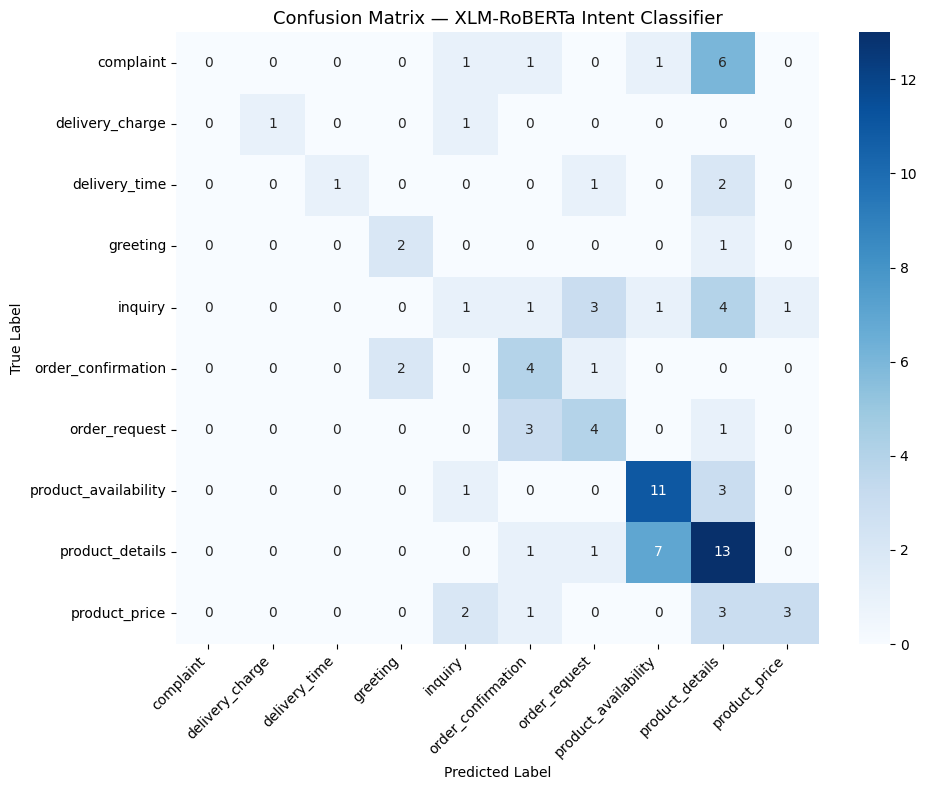

✓ Confusion matrix saved to: /content/drive/MyDrive/ml_project/artifacts/confusion_matrix.png
✓ Results exported to: /content/drive/MyDrive/ml_project/artifacts/model_a_results.json


In [7]:
# ── Run prediction on held-out test set ───────────────────────────────────────
print('Evaluating on test set...')
preds_output = trainer.predict(tok_test)
y_pred = np.argmax(preds_output.predictions, axis=-1)
y_true = preds_output.label_ids

# ── Core metrics ──────────────────────────────────────────────────────────────
test_accuracy = sk_acc(y_true, y_pred)
test_macro_f1 = sk_f1(y_true, y_pred, average='macro', zero_division=0)

print(f'\n── Test Results ───────────────────────────────────────')
print(f'  Accuracy  : {test_accuracy:.4f}')
print(f'  Macro F1  : {test_macro_f1:.4f}')

# ── Per-class classification report (force full label set every run) ──────────
all_label_ids = list(range(num_labels))
target_names = [id2label[i] for i in all_label_ids]
report_str  = classification_report(
    y_true, y_pred,
    labels=all_label_ids,
    target_names=target_names,
    zero_division=0
)
report_dict = classification_report(
    y_true, y_pred,
    labels=all_label_ids,
    target_names=target_names,
    output_dict=True,
    zero_division=0
)
print('\n── Classification Report ──────────────────────────────')
print(report_str)

# ── Confusion matrix heatmap (force full label set every run) ─────────────────
cm = confusion_matrix(y_true, y_pred, labels=all_label_ids)
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True, fmt='d', cmap='Blues',
    xticklabels=target_names,
    yticklabels=target_names
)
plt.title('Confusion Matrix — XLM-RoBERTa Intent Classifier', fontsize=13)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

cm_path = os.path.join(ARTIFACTS_DIR, 'confusion_matrix.png')
plt.savefig(cm_path, dpi=150)
plt.show()
print(f'✓ Confusion matrix saved to: {cm_path}')

# ── Export all metrics to JSON ────────────────────────────────────────────────
results = {
    'run_date'        : datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'dataset_size'    : len(df),
    'num_labels'      : num_labels,
    'accuracy'        : round(test_accuracy, 4),
    'macro_f1'        : round(test_macro_f1, 4),
    'per_class_report': report_dict,
    'label_mapping'   : label_mapping
}
results_path = os.path.join(ARTIFACTS_DIR, 'model_a_results.json')
with open(results_path, 'w', encoding='utf-8') as f:
    json.dump(results, f, ensure_ascii=False, indent=2)
print(f'✓ Results exported to: {results_path}')

## Cell 7 — Inference Function

In [ ]:
# ── Load label mapping from file (so inference is always consistent with the
#    label set used during training, even across re-runs with an updated dataset)
with open(os.path.join(ARTIFACTS_DIR, 'label_mapping.json'), 'r', encoding='utf-8') as f:
    _mapping = json.load(f)
_infer_id2label = {int(k): v for k, v in _mapping['id2label'].items()}

# ── Move model to eval mode ───────────────────────────────────────────────────
model.eval()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

def predict_intent(text: str) -> str:
    """
    Predict the intent of a raw Banglish customer message.

    Args:
        text: Raw string (Banglish / Bangla / English mix)

    Returns:
        Predicted intent label as a string.
    """
    encoding = tokenizer(
        text,
        max_length=MAX_LEN,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
    input_ids      = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        logits = model(input_ids=input_ids, attention_mask=attention_mask).logits

    predicted_id = int(torch.argmax(logits, dim=-1))
    return _infer_id2label[predicted_id]


# ── Test block ────────────────────────────────────────────────────────────────
test_cases = [
    ('Price koto?',                           'product_price'),
    ('Green color hoodie ache?',    'product_availability'),
    ('Order confirm koren',                   'order_confirmation'),
    ('Delivery charge koto?',                 'delivery_charge'),
    ('product quality kharap',                'complaint'),
    ('Koto din e deliver hobe?',              'delivery_time'),
    ('Assalamu Alaikum',                      'greeting'),
    ('Hiw long will it take to deliver',       'inquiry'),
]

print('── Inference Test ─────────────────────────────────────')
print(f'{"Input":<45} {"Predicted":<25} {"Expected"}')
print('-' * 80)
for text, expected in test_cases:
    predicted = predict_intent(text)
    match = '✓' if predicted == expected else '✗'
    print(f'{match} {text:<43} {predicted:<25} {expected}')

── Inference Test ─────────────────────────────────────
Input                                         Predicted                 Expected
--------------------------------------------------------------------------------
✓ Price koto?                                 product_price             product_price
✓ Green color hoodie ache?                    product_availability      product_availability
✓ Order confirm koren                         order_confirmation        order_confirmation
✓ Delivery charge koto?                       delivery_charge           delivery_charge
✗ product quality kharap                      product_details           complaint
✗ Koto din e deliver hobe?                    product_details           delivery_time
✓ Assalamu Alaikum                            greeting                  greeting
✗ Hiw long will it take to deliver            delivery_time             inquiry
